# **SPAM Detection Using NLP & Machine Learning**

## **Data Understand**

In [391]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [392]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [393]:
# Load Dataset
spam_data = pd.read_csv("/content/Spam_Dataset.csv")

In [394]:
# View Dataset
spam_data.head(20)

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [395]:
# Check column columns
spam_data.columns

Index(['Category', 'Masseges'], dtype='object')

## **Data Preprocessing**

In [396]:
# Remove duplicates and spaces in dataset
import string
spam_data['Masseges'] = spam_data['Masseges'].str.replace('','')
spam_data['Masseges'] = spam_data['Masseges'].str.strip()
spam_data = spam_data.drop_duplicates()

In [397]:
# Size of the Dataset after cleantext
spam_data.shape

(5158, 2)

In [398]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5158 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5158 non-null   object
 1   Masseges  5158 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


In [399]:
# Binary Encoding
print(spam_data['Category'].unique())

spam_data['Category'] = spam_data['Category'].map({'ham': 0, 'spam': 1})

['ham' 'spam']


In [400]:
# After Encoding
print(spam_data['Category'].unique())

[0 1]


In [401]:
spam_data.head()

,Category,Masseges
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## **Text Cleaning (NLP Process)**

In [402]:
# import libraries
import re
import string

# Clean Text using NLP
def text_clean(text):
  text = text.lower()
  text = re.sub(r'', '', text)
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'\W', ' ', text)
  text = re.sub(r'\d', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = text.strip()
  words = text.split()
  words = [word for word in words if word not in stop_words]
  return ' '.join(words)

spam_data['Masseges']= spam_data['Masseges'].apply(text_clean)

In [403]:
# Select Features and Target
X = spam_data['Masseges']
y = spam_data['Category']

# Train and Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


## **Feature Extraction : TF-IDF Vectorizer**

In [404]:
# Vectorize Text Features
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.7, min_df=5, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## **Machine Learning**

### **Logistic Regression**

Accuracy: 0.9718992248062015
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       892
           1       0.99      0.80      0.89       140

    accuracy                           0.97      1032
   macro avg       0.98      0.90      0.93      1032
weighted avg       0.97      0.97      0.97      1032

[[891   1]
 [ 28 112]]


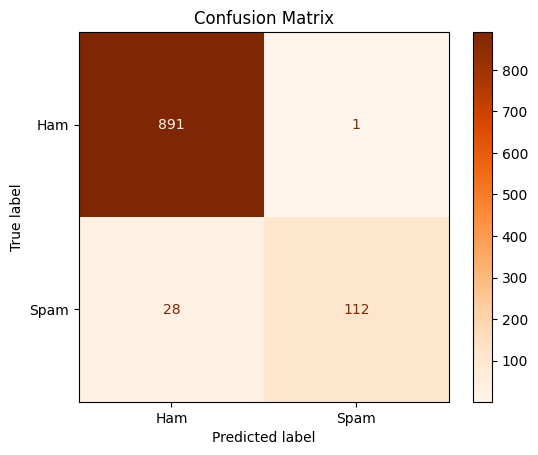

In [405]:
# Import Libraries
from sklearn.linear_model import LogisticRegression

# Model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Prediction:
predict = model.predict(X_test_tfidf)

# Evaluation:
# 1.Accuracy
accuracy = accuracy_score(y_test, predict)
print("Accuracy:", accuracy)

# 2. Classfication Report
cR = classification_report(y_test, predict)
print(cR)

# 3.Confusion Matrix
cm = confusion_matrix(y_test, predict )
print(cm)

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,predict,display_labels = ['Ham','Spam'],cmap="Oranges")
plt.title("Confusion Matrix")
plt.show()

### **Naive Bayes**

********* Naivey Bayes Evaluation ***********

1.Accuracy: 0.9815891472868217
2. Classfication Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       892
           1       0.97      0.89      0.93       140

    accuracy                           0.98      1032
   macro avg       0.98      0.94      0.96      1032
weighted avg       0.98      0.98      0.98      1032

3. Confusion Matrix: 
 [[888   4]
 [ 15 125]]


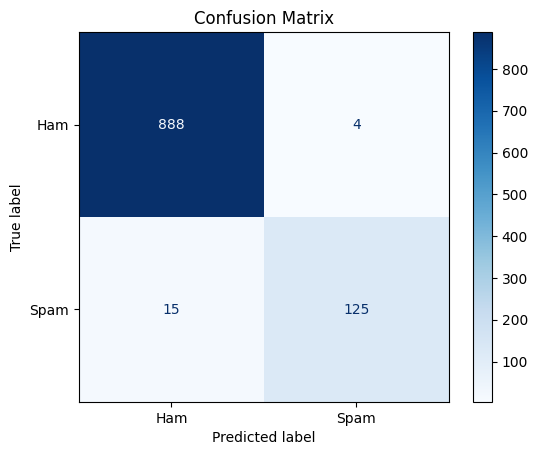

In [406]:
# import libraries
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# prediction
predictions = model.predict(X_test_tfidf)

# Evaluation
print("********* Naivey Bayes Evaluation ***********\n")
accuracy = accuracy_score(y_test, predictions)
print("1.Accuracy:", accuracy)

nb_classification_report = classification_report(y_test, predictions)
print("2. Classfication Report:\n",nb_classification_report)

nb_confusion_matrix = confusion_matrix(y_test, predictions)
print("3. Confusion Matrix: \n", nb_confusion_matrix)

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,predictions,display_labels = ['Ham','Spam'],cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

**Predict Using Sample Data**

In [407]:
# Test Custom Message
sample = ["Congratulations! You won a free ticket"]
sample_tfidf = vectorizer.transform(sample)
prediction = model.predict(sample_tfidf)

print("\nSpam Probability:", prediction)

if prediction[0] == 1:
    print("\nMessage is SPAM")
else:
    print("\nMessage is HAM")


Spam Probability: [1]

Message is SPAM


## **Gradient Boosting Model**

******* Gradient Boosting Model Evaluation *******

1. Accuracy 0.9631782945736435
2. Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       892
           1       0.98      0.74      0.85       140

    accuracy                           0.96      1032
   macro avg       0.97      0.87      0.91      1032
weighted avg       0.96      0.96      0.96      1032

3. Confusion Matrix:
 [[890   2]
 [ 36 104]]


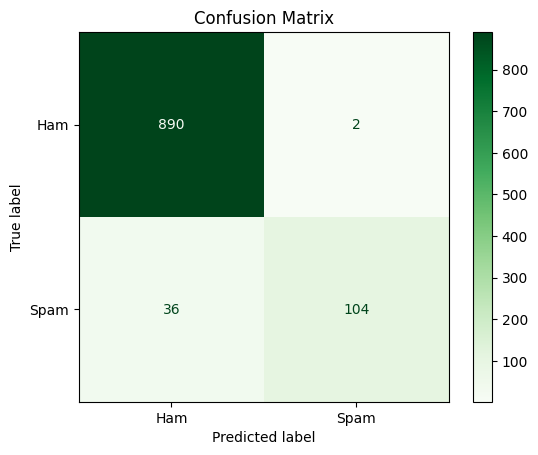

In [408]:
# import libraries
from sklearn.ensemble import GradientBoostingClassifier

# Model
model = GradientBoostingClassifier()
model.fit(X_train_tfidf, y_train)

# prediction
y_prediction = model.predict(X_test_tfidf)

# Evaluation
print("******* Gradient Boosting Model Evaluation *******\n")
accuracy = accuracy_score(y_test, y_prediction)
print("1. Accuracy", accuracy)

gb_classification_report = classification_report(y_test, y_prediction)
print("2. Classification Report:\n", gb_classification_report)

gb_confusion_matrix = confusion_matrix(y_test, y_prediction)
print("3. Confusion Matrix:\n", gb_confusion_matrix)

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_prediction,display_labels = ['Ham','Spam'],cmap="Greens")
plt.title("Confusion Matrix")
plt.show()

# **Conclusion:**

>Among the three models evaluated, **Naïve Bayes** performed the best for spam detection. It achieved the highest accuracy (**98.15%**), highest F1-score for spam (**0.93**), and lowest number of false negatives (**15**). Since minimizing missed spam messages is critical in spam filtering systems, Naïve Bayes is the most suitable model for this dataset.